# Fashion MNIST Classification
This notebook demonstrates various neural network architectures and regularization techniques on the Fashion MNIST dataset.

## 1. Data Loading

In [49]:
from tensorflow import keras

(X_train, y_train), (X_test, y_test) = keras.datasets.fashion_mnist.load_data()

## 2. Data Preprocessing

In [50]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42)

In [51]:
X_train = X_train.astype("float32") / 255.0
X_val = X_val.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

## 3. Data Visualization

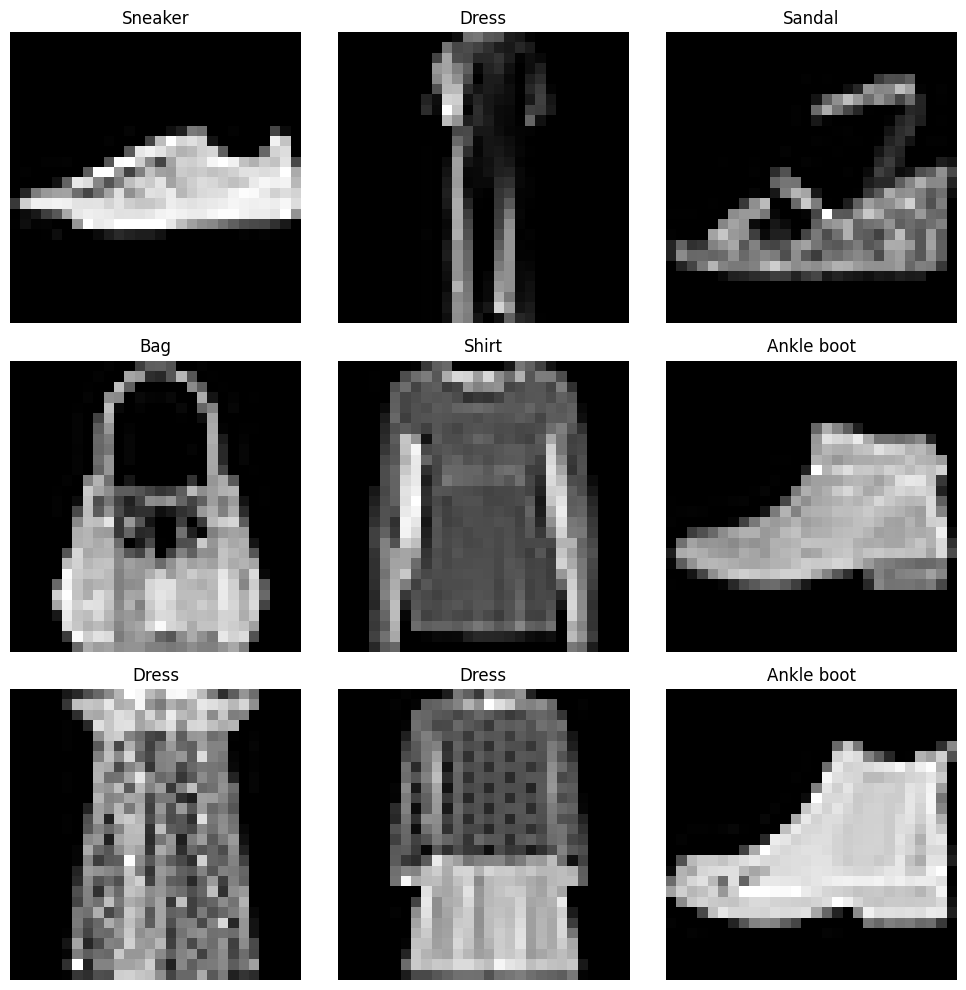

In [52]:
import matplotlib.pyplot as plt

class_names = [
    "T-shirt/top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot"
]

plt.figure(figsize=(10, 10))

for i in range(9):
    plt.subplot(3, 3, i + 1)
    plt.imshow(X_train[i], cmap="gray")
    plt.title(class_names[y_train[i]])
    plt.axis("off")

plt.tight_layout()
plt.show()

## 4. Baseline Model Development

In [53]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, Dense

baseline_model = Sequential([
    Flatten(input_shape=(28,28)),
    Dense(128, activation='relu'),
    Dense(10, activation='softmax')
])

baseline_model.summary()

Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_10 (Flatten)            │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_28 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

In [54]:
baseline_model.compile(
    optimizer='adam',
    loss=('sparse_categorical_crossentropy'),
    metrics=['accuracy']
)

In [55]:
from sklearn.utils.validation import validate_data
history_basline = baseline_model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=10,
    verbose=1
)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.8197 - loss: 0.5145 - val_accuracy: 0.8522 - val_loss: 0.4102
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8610 - loss: 0.3853 - val_accuracy: 0.8723 - val_loss: 0.3579
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8731 - loss: 0.3476 - val_accuracy: 0.8731 - val_loss: 0.3515
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8823 - loss: 0.3186 - val_accuracy: 0.8767 - val_loss: 0.3415
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8908 - loss: 0.3001 - val_accuracy: 0.8798 - val_loss: 0.3335
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8935 - loss: 0.2851 - val_accuracy: 0.8818 - val_loss: 0.3323
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8991 - loss: 0.2721 - val_accuracy: 0.8752 - val_loss: 0.3549
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9029 - loss: 0.2608 - 

## 5. Baseline Evaluation

In [56]:
test_loss, test_accuracy = baseline_model.evaluate(X_test, y_test, verbose=0)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

Test Loss: 0.3418
Test Accuracy: 0.8819


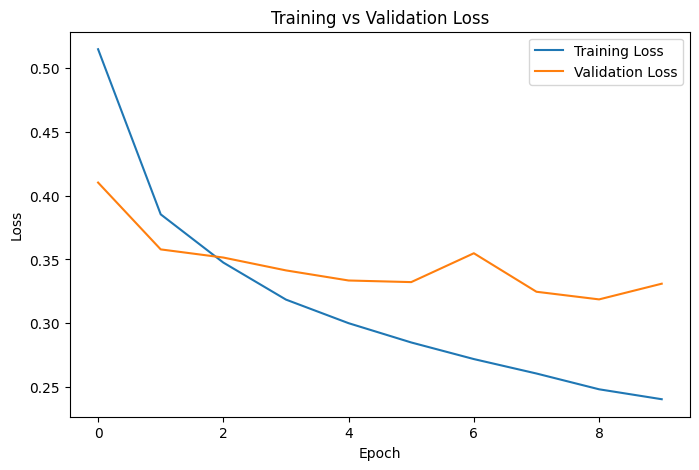

In [57]:
plt.figure(figsize=(8,5))

plt.plot(history_basline.history["loss"], label="Training Loss")
plt.plot(history_basline.history["val_loss"], label="Validation Loss")

plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

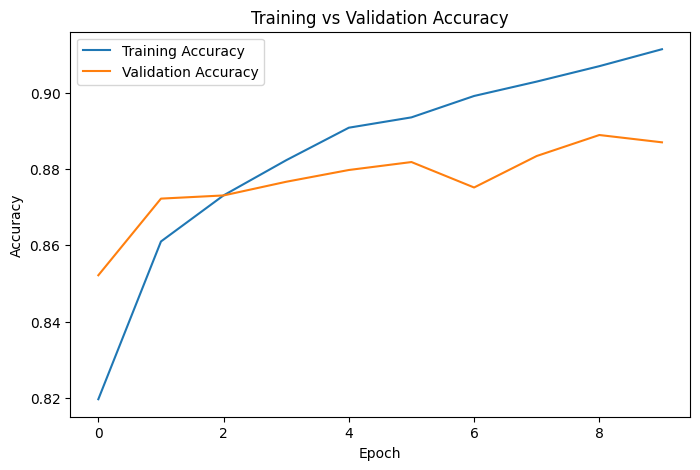

In [58]:
plt.figure(figsize=(8,5))

plt.plot(history_basline.history["accuracy"], label="Training Accuracy")
plt.plot(history_basline.history["val_accuracy"], label="Validation Accuracy")

plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

## 6. Model Utilities & Experiment Builder


In [59]:
def compile_model(model):
    model.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

In [60]:
import time

def train_model(model, x_train, y_train, x_val, y_val):

    start_time = time.time()

    history = model.fit(
        x_train,
        y_train,
        validation_data=(x_val, y_val),
        epochs=10,
        verbose=1
    )

    training_time = time.time() - start_time

    return history, training_time

In [61]:
from tensorflow.keras.layers import  Dropout
from tensorflow.keras import regularizers

In [62]:
def build_experiment1():

    model = Sequential([
        Flatten(input_shape=(28, 28)),
        Dense(128, activation="relu"),
        Dense(64, activation="relu"),
        Dense(10, activation="softmax")
    ])

    return model

In [63]:
def build_experiment2():

    model = Sequential([
        Flatten(input_shape=(28, 28)),
        Dense(128, activation="relu"),
        Dropout(0.3),
        Dense(10, activation="softmax")
    ])

    return model

In [64]:
def build_experiment3():

    model = Sequential([
        Flatten(input_shape=(28, 28)),
        Dense(
            128,
            activation="relu",
            kernel_regularizer=regularizers.l2(0.001)
        ),
        Dense(10, activation="softmax")
    ])

    return model

## 7. Running Experiments (1-3)

In [65]:
exp1_model = build_experiment1()
compile_model(exp1_model)

history_exp1, exp1_time = train_model(
    exp1_model,
    X_train,
    y_train,
    X_val,
    y_val
)

exp2_model = build_experiment2()
compile_model(exp2_model)

history_exp2, exp2_time = train_model(
    exp2_model,
    X_train,
    y_train,
    X_val,
    y_val
)

exp3_model = build_experiment3()
compile_model(exp3_model)

history_exp3, exp3_time = train_model(
    exp3_model,
    X_train,
    y_train,
    X_val,
    y_val
)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.8201 - loss: 0.5110 - val_accuracy: 0.8482 - val_loss: 0.4141
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8608 - loss: 0.3776 - val_accuracy: 0.8718 - val_loss: 0.3647
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.8770 - loss: 0.3387 - val_accuracy: 0.8643 - val_loss: 0.3750
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8837 - loss: 0.3155 - val_accuracy: 0.8789 - val_loss: 0.3382
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8904 - loss: 0.2969 - val_accuracy: 0.8811 - val_loss: 0.3300
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8953 - loss: 0.2827 - val_accuracy: 0.8829 - val_loss: 0.3312
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8993 - loss: 0.2718 - val_accuracy: 0.8813 - val_loss: 0.3452
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9039 - loss: 0.2591 - 

## 8. Summary of Experiments 1-3

In [66]:
def plot_history(history, title):

    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(history.history["accuracy"], label="Train")
    plt.plot(history.history["val_accuracy"], label="Validation")
    plt.title(f"{title} - Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.grid(True)

    plt.subplot(1, 2, 2)
    plt.plot(history.history["loss"], label="Train")
    plt.plot(history.history["val_loss"], label="Validation")
    plt.title(f"{title} - Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

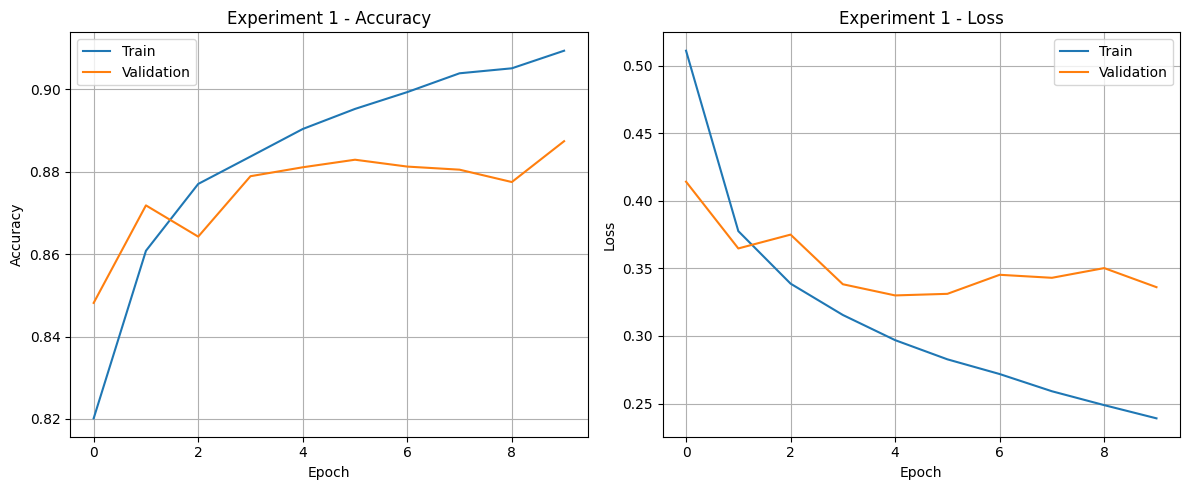

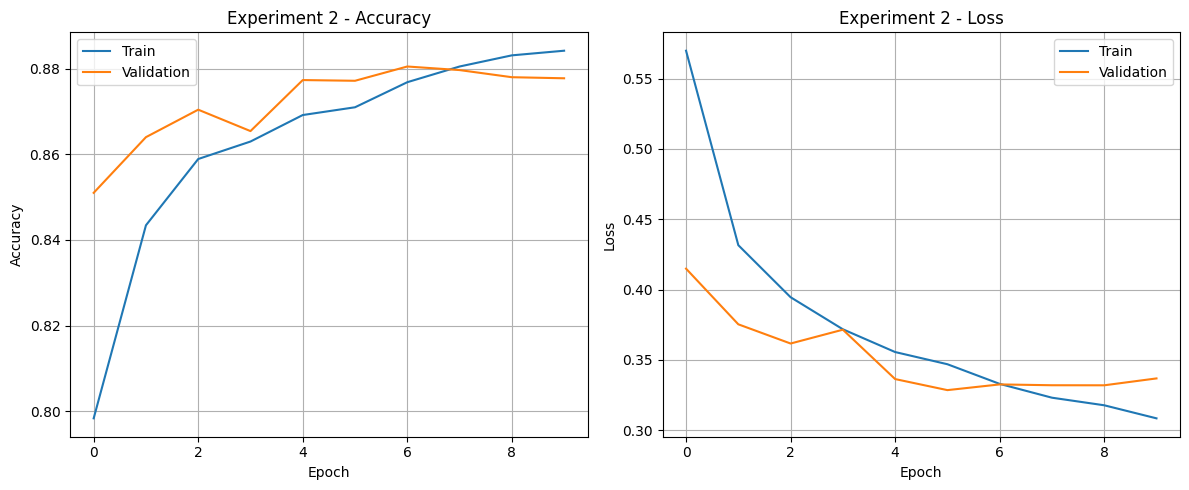

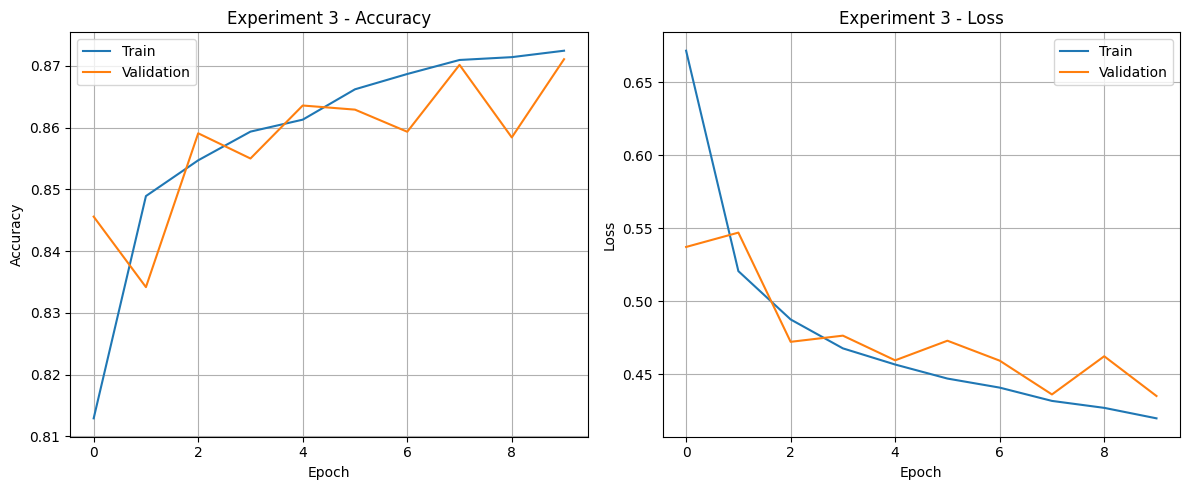

In [67]:
plot_history(history_exp1, "Experiment 1")
plot_history(history_exp2, "Experiment 2")
plot_history(history_exp3, "Experiment 3")

In [68]:
import time

def summarize_model(model, history, X_test, y_test, name, training_time):

    test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)

    train_acc = history.history["accuracy"][-1]
    val_acc = history.history["val_accuracy"][-1]

    train_loss = history.history["loss"][-1]
    val_loss = history.history["val_loss"][-1]

    gap = train_acc - val_acc

    print("=" * 60)
    print(name)
    print("=" * 60)

    print(f"Trainable Parameters : {model.count_params()}")
    print(f"Training Time        : {training_time:.2f} seconds")

    print(f"\nTraining Accuracy    : {train_acc:.4f}")
    print(f"Validation Accuracy  : {val_acc:.4f}")
    print(f"Test Accuracy        : {test_acc:.4f}")

    print(f"\nTraining Loss        : {train_loss:.4f}")
    print(f"Validation Loss      : {val_loss:.4f}")
    print(f"Test Loss            : {test_loss:.4f}")

    print(f"\nTrain-Validation Gap : {gap:.4f}")

    print("=" * 60)

In [69]:
summarize_model(
    exp1_model,
    history_exp1,
    X_test,
    y_test,
    "Experiment 1",
    exp1_time
)

summarize_model(
    baseline_model,
    history_exp2,
    X_test,
    y_test,
    "Experiment 2",
    exp2_time
)

summarize_model(
    exp1_model,
    history_exp3,
    X_test,
    y_test,
    "Experiment 3",
    exp3_time
)

Experiment 1
Trainable Parameters : 109386
Training Time        : 49.59 seconds

Training Accuracy    : 0.9094
Validation Accuracy  : 0.8874
Test Accuracy        : 0.8783

Training Loss        : 0.2390
Validation Loss      : 0.3361
Test Loss            : 0.3556

Train-Validation Gap : 0.0220
Experiment 2
Trainable Parameters : 101770
Training Time        : 48.69 seconds

Training Accuracy    : 0.8842
Validation Accuracy  : 0.8777
Test Accuracy        : 0.8819

Training Loss        : 0.3084
Validation Loss      : 0.3368
Test Loss            : 0.3418

Train-Validation Gap : 0.0064
Experiment 3
Trainable Parameters : 109386
Training Time        : 48.35 seconds

Training Accuracy    : 0.8725
Validation Accuracy  : 0.8711
Test Accuracy        : 0.8783

Training Loss        : 0.4196
Validation Loss      : 0.4350
Test Loss            : 0.3556

Train-Validation Gap : 0.0014


## 9. Experiment 4: Multi-layer Network with L2 & Dropout
This experiment tests a deeper architecture combined with both L2 regularization and Dropout to minimize the generalization gap.

In [70]:
def build_experiment4():

    model = Sequential([
        Flatten(input_shape=(28, 28)),

        Dense(256, activation="relu"),

        Dense(128, activation="relu"),

        Dropout(0.3),

        Dense(10, activation="softmax")
    ])

    return model

In [71]:
exp4_model = build_experiment4()
compile_model(exp4_model)

history_exp4, exp4_time = train_model(
    exp4_model,
    X_train,
    y_train,
    X_val,
    y_val
)


Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.8053 - loss: 0.5387 - val_accuracy: 0.8426 - val_loss: 0.4293
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8565 - loss: 0.3934 - val_accuracy: 0.8714 - val_loss: 0.3496
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8706 - loss: 0.3541 - val_accuracy: 0.8750 - val_loss: 0.3385
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8784 - loss: 0.3295 - val_accuracy: 0.8755 - val_loss: 0.3434
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8858 - loss: 0.3109 - val_accuracy: 0.8792 - val_loss: 0.3283
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8911 - loss: 0.2940 - val_accuracy: 0.8756 - val_loss: 0.3422
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8965 - loss: 0.2815 - val_accuracy: 0.8850 - val_loss: 0.3189
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8992 - loss: 0.2716 - 

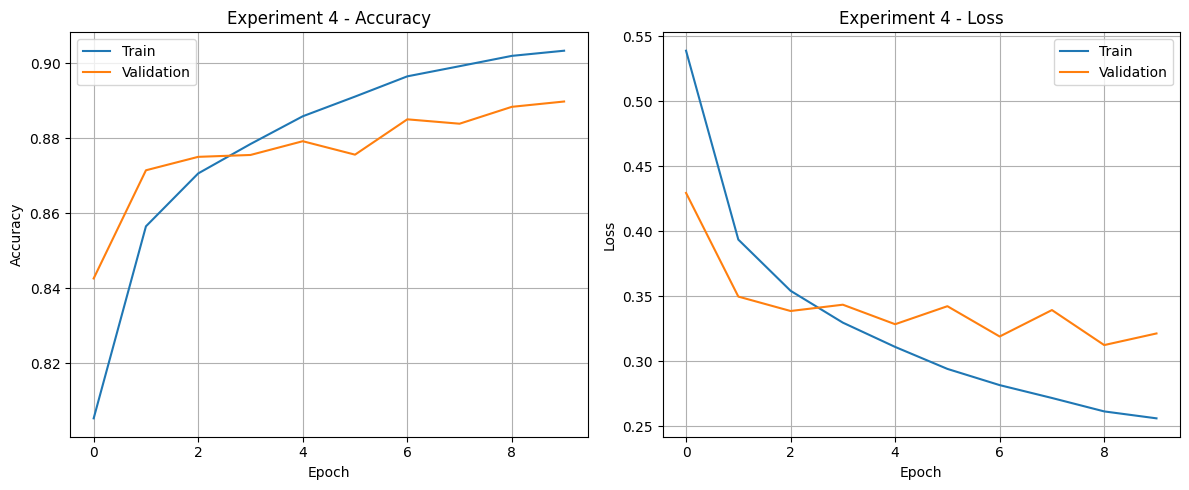

In [72]:
plot_history(history_exp4, "Experiment 4")

## 10. Final Comparison


In [73]:
summarize_model(
    exp4_model,
    history_exp4,
    X_test,
    y_test,
    "Experiment 4",
    exp4_time
)


Experiment 4
Trainable Parameters : 235146
Training Time        : 50.11 seconds

Training Accuracy    : 0.9033
Validation Accuracy  : 0.8898
Test Accuracy        : 0.8826

Training Loss        : 0.2559
Validation Loss      : 0.3212
Test Loss            : 0.3485

Train-Validation Gap : 0.0135


## Final Model Selection

Four neural network architectures were evaluated using the same training, validation, and test datasets.

The comparison showed that **Experiment 4** achieved the highest overall performance. It obtained the **highest test accuracy (88.26%)** and the **highest validation accuracy (88.98%)**, while maintaining a relatively small training-validation gap (0.0135), indicating good generalization to unseen data.

Although **Experiment 2** achieved the smallest training-validation gap (0.0064), its test accuracy (88.19%) was slightly lower than Experiment 4. Likewise, **Experiment 3** produced the smallest gap (0.0014), but its overall classification performance was lower. **Experiment 1** achieved high training accuracy but showed a larger gap between training and validation accuracy, suggesting a higher tendency toward overfitting.

Therefore, **Experiment 4** was selected as the final model because it provided the best balance between predictive performance and generalization. The selected model will be saved as **best_model.keras** for deployment and future inference.

In [74]:
exp4_model.save("best_model.keras")